# Guided Numeric Exploration — Marriage Longevity
_What associates with divorce in a synthetic Gottman-style panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/marriage-longevity-what-makes-relationships-last](https://www.kaggle.com/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate: Outcomes & Horsemen](#Univariate)** <br>
**4. [Divorce Rates by Demographics](#Demographics)** <br>
**5. [Four Horsemen & Positive Ratio](#Horsemen)** <br>
**6. [Protective Factors & Crosstabs](#Protective)** <br>
**7. [Multivariate Association](#Association)** <br>
**8. [Duration Among Divorced](#Duration)** <br>
**9. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 45,000-marriage panel built around Gottman's conflict behaviors (criticism, contempt, defensiveness, stonewalling), repair attempts, the positive-to-negative interaction ratio, and classic demographic risk factors. The binary target is `divorced` (~46%).

I treat associations as properties of the generator, not real relationship science. The data dictionary claims **contempt** is the strongest single predictor and **premarital counseling** is protective — both claims get tested here. `years_to_divorce` is NaN for intact marriages by design (not MAR). `years_married` is partly outcome-tied, so leakage-aware modeling matters.


# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "marriage_longevity_master.csv"
DICT_BASENAME = "data_dictionary.csv"
KAGGLE_SLUG = "sergionefedov/marriage-longevity-what-makes-relationships-last"
EXPECTED_COLS = [
    "marriage_id", "marriage_number", "age_at_marriage", "age_gap_years", "education_level",
    "household_income_usd", "financial_stress", "both_employed", "cohabited_before",
    "premarital_counseling", "child_before_marriage", "n_children", "religious_attendance",
    "criticism", "contempt", "defensiveness", "stonewalling", "repair_attempt_success",
    "positive_negative_ratio", "conflict_frequency_weekly", "shared_activities_weekly",
    "years_married", "years_to_divorce", "divorced",
]


def resolve_csv_path(basename: str) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path(CSV_BASENAME)
dict_path = resolve_csv_path(DICT_BASENAME)
print("CSV:", csv_path)
print("Dictionary:", dict_path)

df = pd.read_csv(csv_path, low_memory=False)
dd = pd.read_csv(dict_path)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 45000, f"expected 45000 rows, got {len(df)}"
assert df["divorced"].isin([0, 1]).all()
# years_to_divorce NaN only when still married
assert df.loc[df["divorced"] == 0, "years_to_divorce"].isna().all()
assert df.loc[df["divorced"] == 1, "years_to_divorce"].notna().all()

print("Missing Values (excl. years_to_divorce design NaNs):",
      int(df.drop(columns=["years_to_divorce"]).isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Divorce rate:", round(df["divorced"].mean(), 4))
display(dd)
display(df.sample(5, random_state=42))


CSV: /Users/nicapotato/.cache/kagglehub/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/versions/1/marriage_longevity_master.csv
Dictionary: /Users/nicapotato/.cache/kagglehub/datasets/sergionefedov/marriage-longevity-what-makes-relationships-last/versions/1/data_dictionary.csv
Missing Values (excl. years_to_divorce design NaNs): 0
Dataframe Dimension: 45000 Rows, 24 Columns
Divorce rate: 0.4602


,column,type,description
0,marriage_id,string,Unique marriage id
1,marriage_number,int,"1st, 2nd or 3rd marriage — one of the stronges..."
2,age_at_marriage,int,Age at the start of this marriage
3,age_gap_years,int,Age difference between partners
4,education_level,string,less_than_hs / high_school / some_college / ba...
5,household_income_usd,float,Household income (USD)
6,financial_stress,float,Self-reported financial stress (0-10)
7,both_employed,int,1 if both partners employed
8,cohabited_before,int,1 if the couple cohabited before marrying
9,premarital_counseling,int,1 if they did premarital counselling — a prote...


,marriage_id,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,n_children,religious_attendance,criticism,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
37979,MAR037979,2,36,8,bachelors,147300.0,7.1,1,0,1,0,2,rarely,6.7,0.6,8.0,7.4,6.2,6.30,3.0,5.0,8.9,NaN,0
9911,MAR009911,1,30,2,graduate,95800.0,4.7,1,0,0,0,1,never,7.8,5.0,9.0,6.3,6.1,1.89,4.0,4.0,5.4,NaN,0
43386,MAR043386,1,24,1,graduate,120900.0,4.9,0,0,0,0,1,never,4.2,2.3,1.0,6.3,4.9,2.49,0.0,1.0,5.6,NaN,0
13822,MAR013822,1,33,8,graduate,79100.0,3.7,1,0,0,0,0,monthly,6.7,0.2,9.8,5.2,3.3,2.24,3.0,3.0,8.5,8.5,1
44810,MAR044810,1,36,3,high_school,80900.0,7.9,1,0,0,0,2,never,5.0,0.7,6.4,2.4,8.5,3.41,3.0,1.0,19.6,NaN,0


**Code Explanation and Reasoning:** <br>
Schema, row count, and the design of `years_to_divorce` (NaN iff intact) are asserted. The dictionary table is shown so later sections can test its claims against the generator.


In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
horsemen = ["criticism", "contempt", "defensiveness", "stonewalling"]
df[horsemen + ["positive_negative_ratio", "financial_stress", "years_married", "age_at_marriage"]].describe().T.round(2)


,Column,Unique,Null
0,marriage_id,45000,0
5,household_income_usd,3945,0
18,positive_negative_ratio,1636,0
21,years_married,509,0
22,years_to_divorce,321,24292
6,financial_stress,101,0
17,repair_attempt_success,101,0
13,criticism,101,0
14,contempt,101,0
15,defensiveness,101,0


,count,mean,std,min,25%,50%,75%,max
criticism,45000.0,4.48,2.18,0.0,3.00,4.50,6.00,10.0
contempt,45000.0,3.26,2.18,0.0,1.60,3.20,4.80,10.0
defensiveness,45000.0,4.76,2.15,0.0,3.30,4.80,6.20,10.0
stonewalling,45000.0,3.80,2.17,0.0,2.20,3.80,5.30,10.0
positive_negative_ratio,45000.0,4.01,2.85,0.2,2.08,3.26,5.06,20.0
financial_stress,45000.0,5.19,2.36,0.0,3.60,5.20,6.80,10.0
years_married,45000.0,10.70,7.82,0.5,5.10,8.70,14.00,55.0
age_at_marriage,45000.0,30.17,7.59,16.0,25.00,29.00,34.00,68.0


**Interpretation** <br>
Divorce is nearly balanced (~46%). Horsemen scores span 0–10; `positive_negative_ratio` is right-skewed. Demographic and behavioral axes are both populated — good for comparing dictionary claims about contempt vs counseling.


# **3. Univariate: Outcomes & Horsemen:** <a id="Univariate"></a>

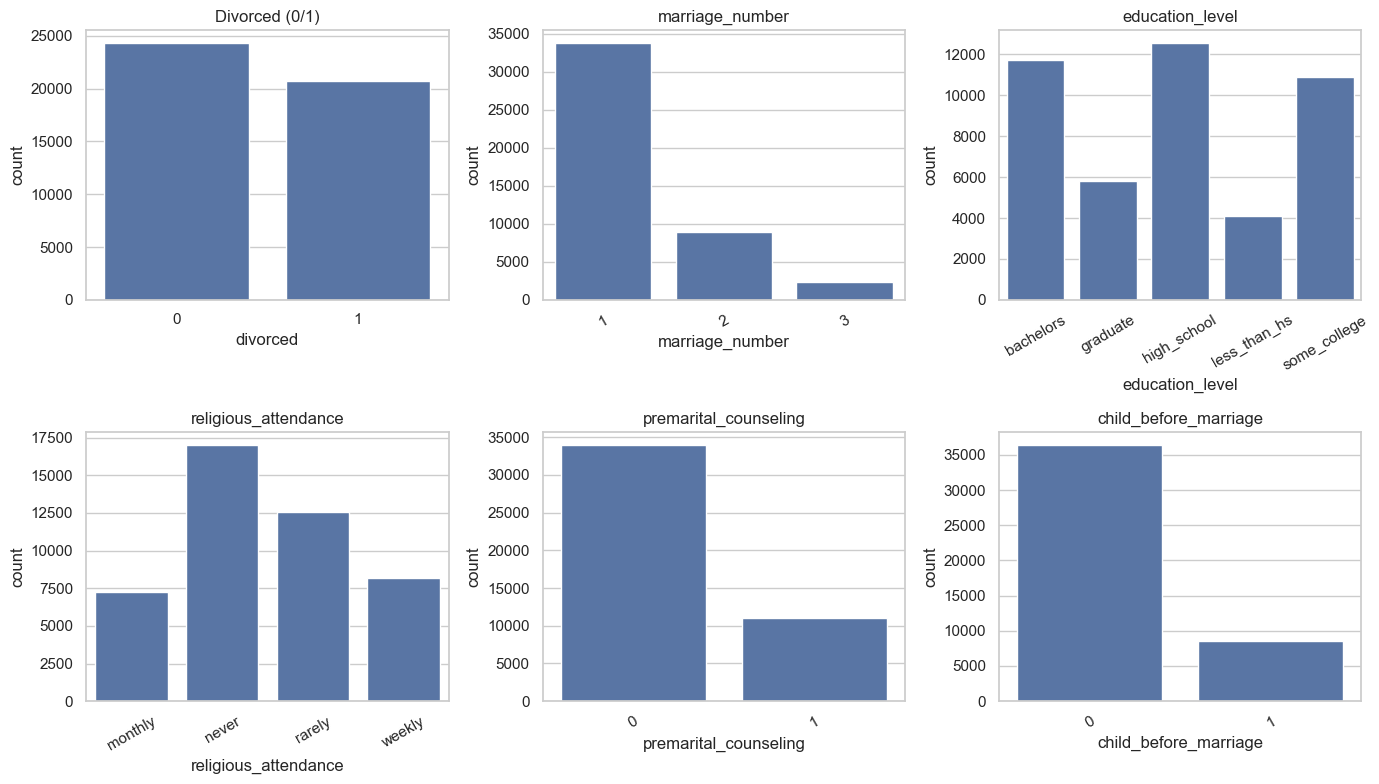

In [4]:
# Outcome and key categoricals
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

sns.countplot(data=df, x="divorced", ax=axes[0])
axes[0].set_title("Divorced (0/1)")

for ax, col in zip(axes[1:], ["marriage_number", "education_level", "religious_attendance",
                               "premarital_counseling", "child_before_marriage"]):
    order = df[col].value_counts().index if df[col].dtype == object else sorted(df[col].unique())
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


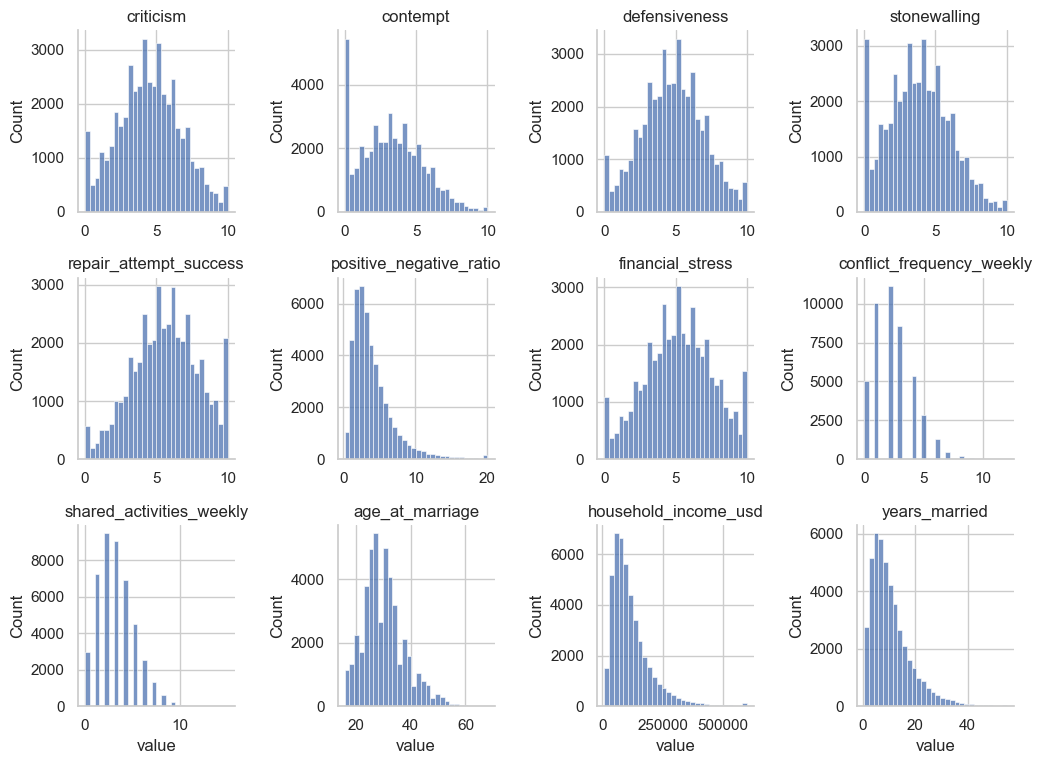

In [5]:
# Continuous distributions
cont_cols = horsemen + [
    "repair_attempt_success", "positive_negative_ratio", "financial_stress",
    "conflict_frequency_weekly", "shared_activities_weekly", "age_at_marriage",
    "household_income_usd", "years_married",
]
melt = df[cont_cols].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(melt, col="feature", col_wrap=4, sharex=False, sharey=False, height=2.6)
g.map_dataframe(sns.histplot, x="value", bins=30)
g.set_titles("{col_name}")
plt.show()


**Interpretation** <br>
First marriages dominate; education is mid-heavy. Horsemen are unimodal across the 0–10 scale. Income is right-skewed — later plots should prefer rates/medians over means when slicing by income.


# **4. Divorce Rates by Demographics:** <a id="Demographics"></a>

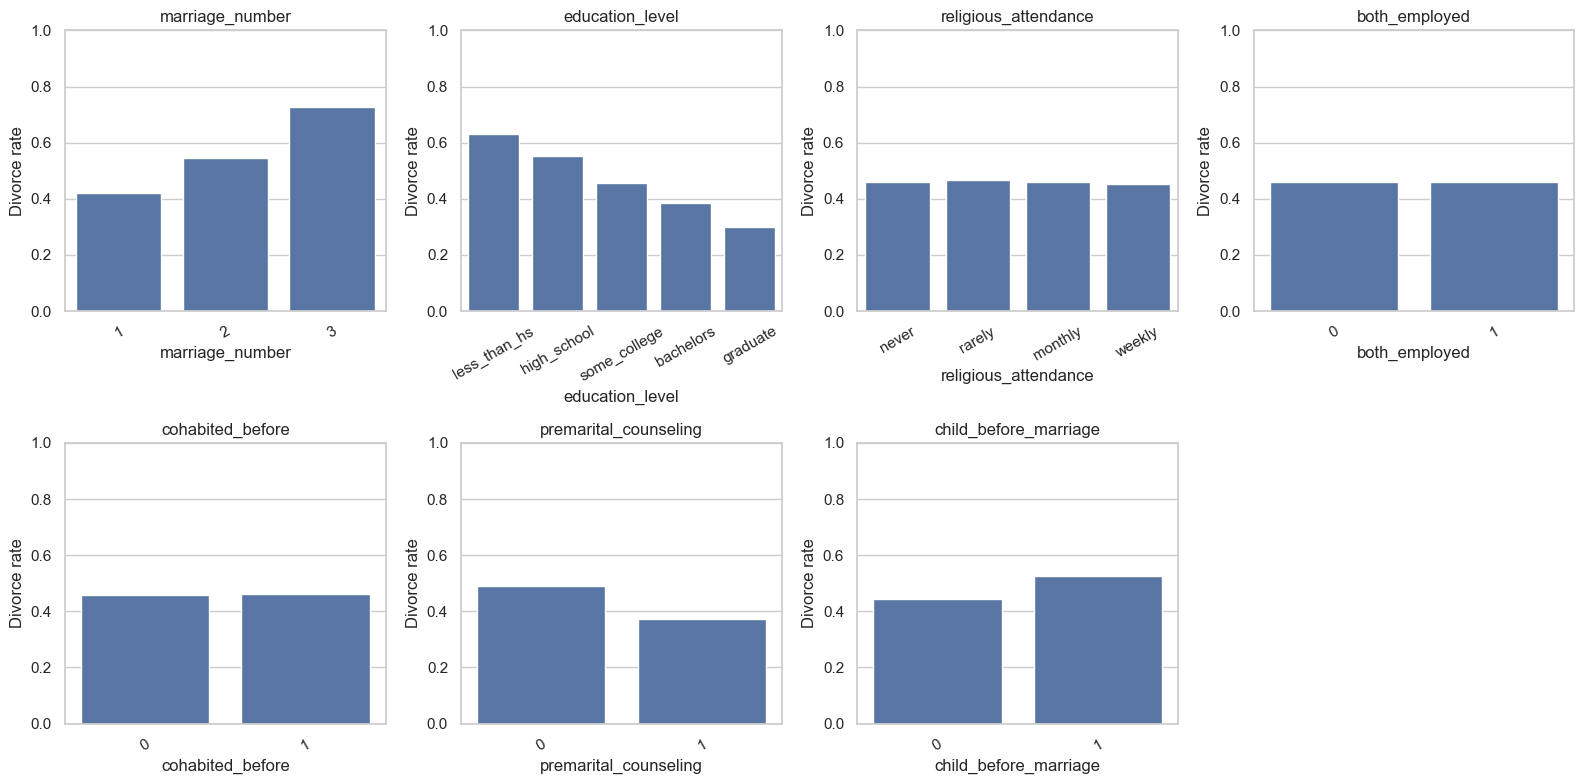


=== marriage_number × divorced (row %) ===


divorced,0,1
marriage_number,,
1,0.580,0.420
2,0.456,0.544
3,0.274,0.726



=== education_level × divorced (row %) ===


divorced,0,1
education_level,,
bachelors,0.615,0.385
graduate,0.701,0.299
high_school,0.448,0.552
less_than_hs,0.369,0.631
some_college,0.543,0.457



=== religious_attendance × divorced (row %) ===


...

divorced,0,1
cohabited_before,,
0,0.543,0.457
1,0.538,0.462



=== premarital_counseling × divorced (row %) ===


divorced,0,1
premarital_counseling,,
0,0.511,0.489
1,0.628,0.372



=== child_before_marriage × divorced (row %) ===


divorced,0,1
child_before_marriage,,
0,0.555,0.445
1,0.473,0.527


In [6]:
# Divorce rate by categorical factors
cat_cols = ["marriage_number", "education_level", "religious_attendance",
            "both_employed", "cohabited_before", "premarital_counseling", "child_before_marriage"]

edu_order = ["less_than_hs", "high_school", "some_college", "bachelors", "graduate"]
rel_order = ["never", "rarely", "monthly", "weekly"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["divorced"].agg(["mean", "count"]).reset_index()
    if col == "education_level":
        rates[col] = pd.Categorical(rates[col], categories=edu_order, ordered=True)
        rates = rates.sort_values(col)
    elif col == "religious_attendance":
        rates[col] = pd.Categorical(rates[col], categories=rel_order, ordered=True)
        rates = rates.sort_values(col)
    sns.barplot(data=rates, x=col, y="mean", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Divorce rate")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

for col in cat_cols:
    tab = pd.crosstab(df[col], df["divorced"], normalize="index").round(3)
    print(f"\n=== {col} × divorced (row %) ===")
    display(tab)


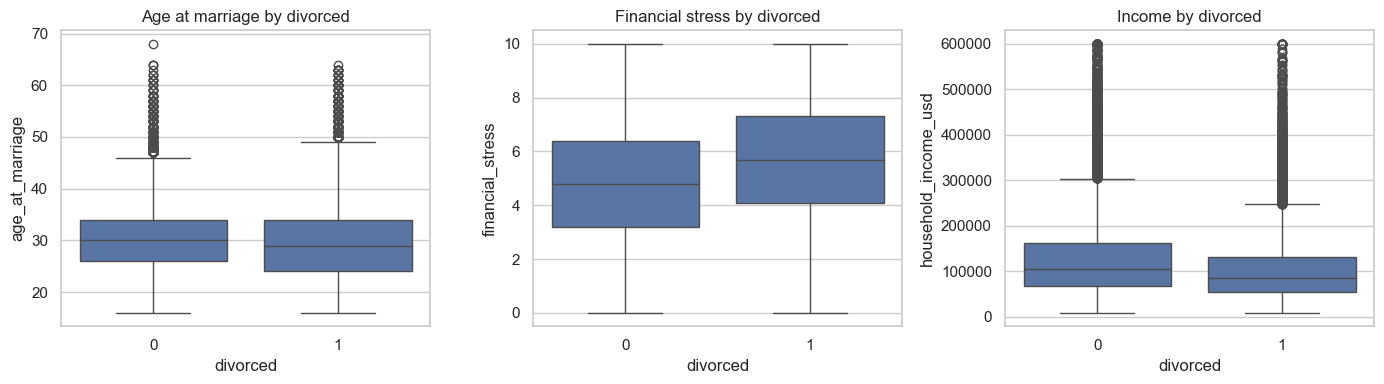

In [7]:
# Age at marriage and income stress vs divorce
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=df, x="divorced", y="age_at_marriage", ax=axes[0])
axes[0].set_title("Age at marriage by divorced")
sns.boxplot(data=df, x="divorced", y="financial_stress", ax=axes[1])
axes[1].set_title("Financial stress by divorced")
sns.boxplot(data=df, x="divorced", y="household_income_usd", ax=axes[2])
axes[2].set_title("Income by divorced")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Higher marriage number and child-before-marriage raise divorce rates; counseling and weekly religious attendance sit lower. Financial stress separates outcomes more cleanly than raw income — next check whether stress survives horsemen controls.


# **5. Four Horsemen & Positive Ratio:** <a id="Horsemen"></a>

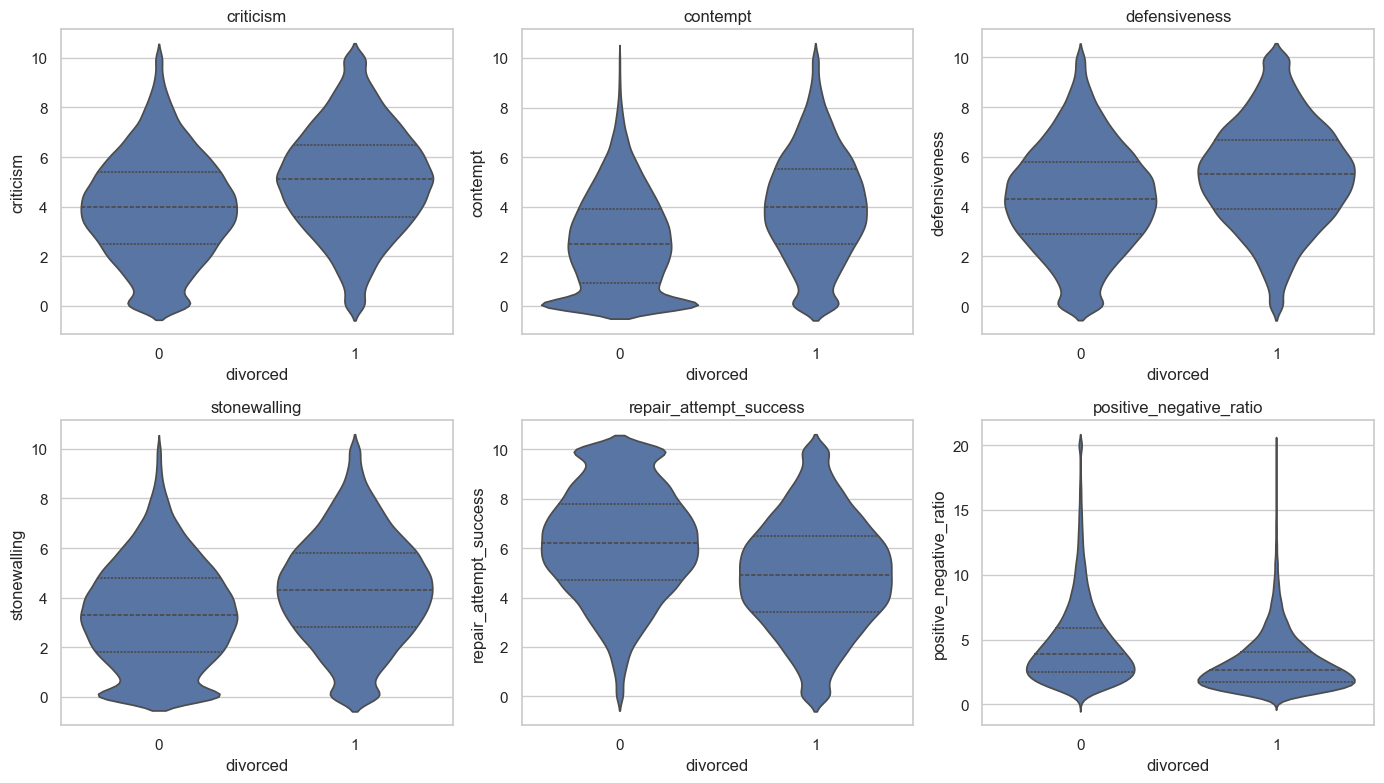

,feature,mean_intact,mean_divorced,diff_divorced_minus_intact,cohen_d
1,contempt,2.592,4.036,1.443,0.698
4,repair_attempt_success,6.216,4.939,-1.277,-0.582
5,positive_negative_ratio,4.689,3.217,-1.471,-0.541
0,criticism,3.978,5.077,1.099,0.521
3,stonewalling,3.357,4.324,0.967,0.457
2,defensiveness,4.319,5.278,0.959,0.457
7,shared_activities_weekly,3.420,2.584,-0.835,-0.448
6,conflict_frequency_weekly,2.081,2.727,0.646,0.396


In [8]:
# Horsemen and PN ratio by divorce outcome
plot_cols = horsemen + ["repair_attempt_success", "positive_negative_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    sns.violinplot(data=df, x="divorced", y=col, inner="quartile", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Mean difference table
summary = []
for col in plot_cols + ["conflict_frequency_weekly", "shared_activities_weekly"]:
    g0 = df.loc[df["divorced"] == 0, col]
    g1 = df.loc[df["divorced"] == 1, col]
    summary.append({
        "feature": col,
        "mean_intact": g0.mean(),
        "mean_divorced": g1.mean(),
        "diff_divorced_minus_intact": g1.mean() - g0.mean(),
        "cohen_d": (g1.mean() - g0.mean()) / np.sqrt((g0.var() + g1.var()) / 2),
    })
summary_df = pd.DataFrame(summary).sort_values("cohen_d", key=abs, ascending=False)
display(summary_df.round(3))


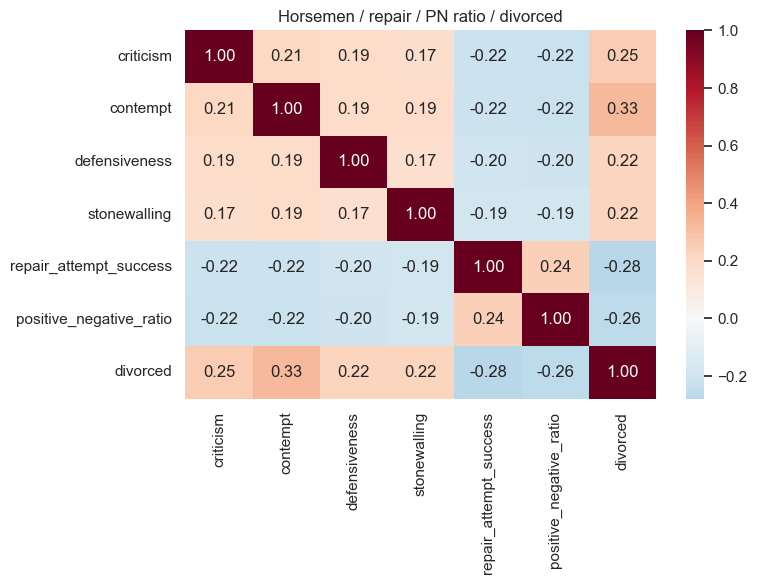

,mean,count
pn_bin,,
<1,0.761032,1745
1–3,0.575126,18582
3–5,0.418233,13196
5–8,0.310793,7690
>8,0.207024,3787


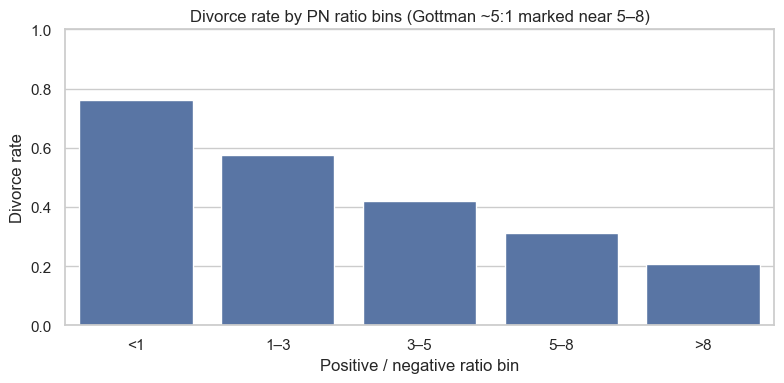

In [9]:
# Horsemen correlation + PN ratio threshold
corr = df[horsemen + ["repair_attempt_success", "positive_negative_ratio", "divorced"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Horsemen / repair / PN ratio / divorced")
plt.tight_layout()
plt.show()

# Divorce rate by PN ratio bins around Gottman 5:1
df = df.copy()
df["pn_bin"] = pd.cut(
    df["positive_negative_ratio"],
    bins=[-np.inf, 1, 3, 5, 8, np.inf],
    labels=["<1", "1–3", "3–5", "5–8", ">8"],
)
pn_rates = df.groupby("pn_bin", observed=True)["divorced"].agg(["mean", "count"])
display(pn_rates)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=pn_rates.index.astype(str), y=pn_rates["mean"], ax=ax)
ax.set_ylabel("Divorce rate")
ax.set_xlabel("Positive / negative ratio bin")
ax.set_title("Divorce rate by PN ratio bins (Gottman ~5:1 marked near 5–8)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Contempt and low PN ratio show the largest standardized gaps. Horsemen are positively correlated with each other — they are not independent axes. Divorce falls sharply as the PN ratio crosses into the 5+ region, consistent with the dictionary's Gottman framing inside this generator.


# **6. Protective Factors & Crosstabs:** <a id="Protective"></a>

divorced                                    0      1
premarital_counseling cohabited_before              
0                     0                 0.512  0.488
                      1                 0.511  0.489
1                     0                 0.639  0.361
                      1                 0.621  0.379

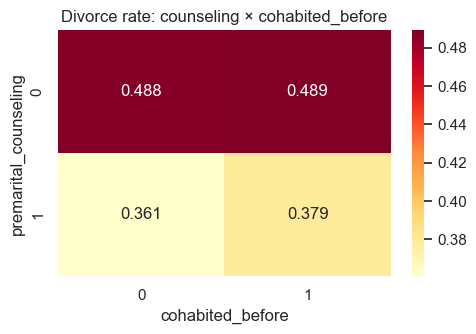

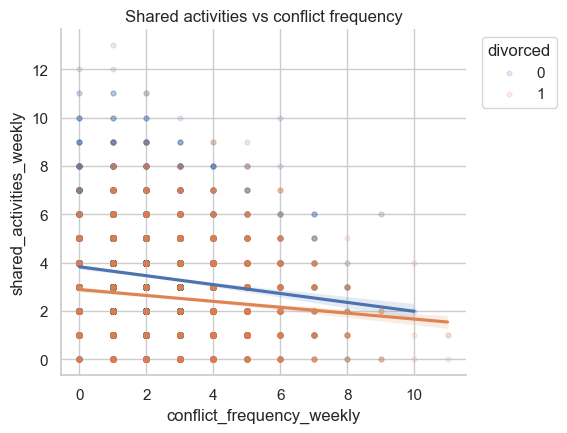

In [10]:
# Counseling × cohabitation divorce rates
ct = pd.crosstab(
    [df["premarital_counseling"], df["cohabited_before"]],
    df["divorced"],
    normalize="index",
).round(3)
display(ct)

heat = df.pivot_table(
    index="premarital_counseling",
    columns="cohabited_before",
    values="divorced",
    aggfunc="mean",
)
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
ax.set_title("Divorce rate: counseling × cohabited_before")
plt.tight_layout()
plt.show()

# Conflict frequency vs shared activities, hue=divorced
sns.lmplot(
    data=df.sample(8000, random_state=0),
    x="conflict_frequency_weekly",
    y="shared_activities_weekly",
    hue="divorced",
    scatter_kws={"alpha": 0.15, "s": 12},
    height=4.5,
    aspect=1.3,
    legend=False,
)
plt.legend(title="divorced", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Shared activities vs conflict frequency")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Counseling associates with lower divorce rates in both cohabitation strata — dictionary claim holds directionally here. Shared activities and conflict pull in opposite directions; the next section asks which behavioral signals dominate after demographics enter.


# **7. Multivariate Association:** <a id="Association"></a>

,importance
contempt,0.158145
positive_negative_ratio,0.115756
repair_attempt_success,0.104863
criticism,0.080994
defensiveness,0.066750
stonewalling,0.065362
household_income_usd,0.058347
financial_stress,0.057044
age_at_marriage,0.047455
marriage_number,0.041689


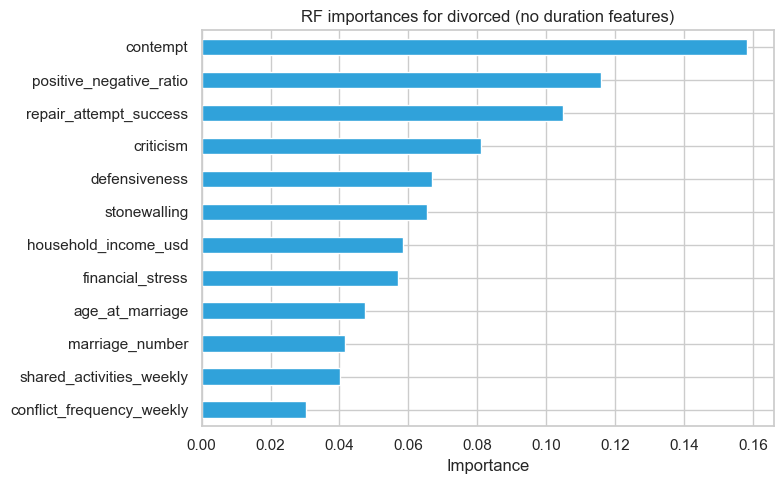

In-sample accuracy: 0.867


In [11]:
# RF importances for divorced — exclude years_married / years_to_divorce (duration leakage)
feature_cols = [
    "marriage_number", "age_at_marriage", "age_gap_years", "education_level",
    "household_income_usd", "financial_stress", "both_employed", "cohabited_before",
    "premarital_counseling", "child_before_marriage", "n_children", "religious_attendance",
    "criticism", "contempt", "defensiveness", "stonewalling", "repair_attempt_success",
    "positive_negative_ratio", "conflict_frequency_weekly", "shared_activities_weekly",
]
X = df[feature_cols]
y = df["divorced"]

cat = ["education_level", "religious_attendance"]
num = [c for c in feature_cols if c not in cat]

pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
])
pipe.fit(X, y)
rf = pipe.named_steps["rf"]
ohe = pipe.named_steps["pre"].named_transformers_["cat"]
names = num + list(ohe.get_feature_names_out(cat))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)
display(imp.head(15).to_frame("importance"))

fig, ax = plt.subplots(figsize=(8, 5))
imp.head(12).sort_values().plot(kind="barh", ax=ax, color="#30a2da")
ax.set_title("RF importances for divorced (no duration features)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print("In-sample accuracy:", round(pipe.score(X, y), 3))


premarital_counseling,0,1
contempt_tert,,
low,0.302,0.210
mid,0.486,0.373
high,0.677,0.560


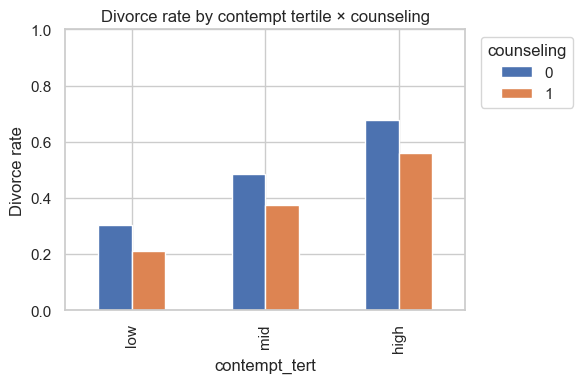

In [12]:
# Stratified divorce rate by contempt tertile × counseling
df["contempt_tert"] = pd.qcut(df["contempt"], 3, labels=["low", "mid", "high"])
strat = df.groupby(["contempt_tert", "premarital_counseling"], observed=True)["divorced"].mean().unstack()
display(strat.round(3))
fig, ax = plt.subplots(figsize=(6, 4))
strat.plot(kind="bar", ax=ax)
ax.set_ylabel("Divorce rate")
ax.set_title("Divorce rate by contempt tertile × counseling")
ax.legend(title="counseling", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Without duration leakage, behavioral features (contempt, PN ratio, repair) dominate RF importance — matching the dictionary's emphasis. Counseling still separates rates inside each contempt tertile, so the protective claim is not just a low-contempt selection artifact in this generator.


# **8. Duration Among Divorced:** <a id="Duration"></a>

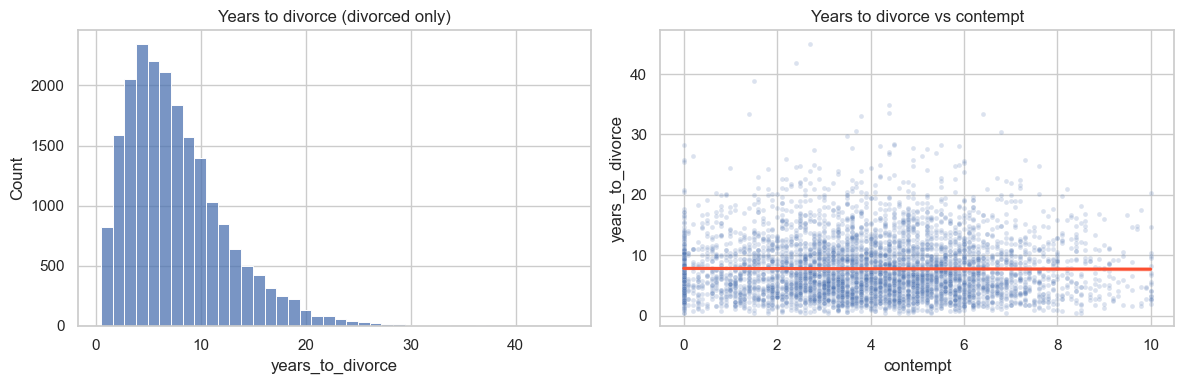

Spearman contempt vs years_to_divorce: 0.003


In [13]:
# Among divorced: years_to_divorce vs contempt
div = df[df["divorced"] == 1].copy()
assert div["years_to_divorce"].notna().all()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(div["years_to_divorce"], bins=40, ax=axes[0])
axes[0].set_title("Years to divorce (divorced only)")
sns.scatterplot(
    data=div.sample(min(5000, len(div)), random_state=1),
    x="contempt", y="years_to_divorce", alpha=0.2, s=12, ax=axes[1],
)
sns.regplot(
    data=div.sample(min(5000, len(div)), random_state=1),
    x="contempt", y="years_to_divorce", scatter=False, ax=axes[1], color="#fc4f30",
)
axes[1].set_title("Years to divorce vs contempt")
plt.tight_layout()
plt.show()
print("Spearman contempt vs years_to_divorce:",
      round(stats.spearmanr(div["contempt"], div["years_to_divorce"]).statistic, 3))


**Interpretation** <br>
Among marriages that end, higher contempt associates with shorter time-to-divorce. This is a duration story conditional on divorce — not a claim about who divorces.


# **9. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic marriage panel with Gottman conflict scores, protective factors, and a binary divorce target.

**Working takeaways:** <br>
- Divorce rate is ~46%; remarriage number and child-before-marriage raise rates; counseling and weekly religious attendance sit lower.
- Among horsemen, contempt and a low positive/negative ratio show the largest outcome gaps; horsemen are intercorrelated.
- PN-ratio bins around Gottman's ~5:1 threshold separate divorce rates sharply in this generator.
- Financial stress tracks divorce more cleanly than raw household income.
- RF importances (excluding duration leakage) rank behavioral features ahead of most demographics; counseling still helps inside contempt tertiles.
- Among divorced couples, higher contempt associates with shorter `years_to_divorce`.

**Open follow-ups:** <br>
- Logistic partial effects of repair success at fixed conflict frequency.
- Whether income retains any signal after residualizing on financial_stress.
- Interaction of education × religious attendance on divorce rates.
